In [80]:
import torch #Libraries installation
import torchvision
import numpy as np
import matplotlib.pyplot as plt

from datasets import load_dataset
from diffusers import UNet2DModel
from diffusers import DDPMScheduler

In [81]:
from datasets import load_dataset # dataset loading

dataset = load_dataset("huggan/smithsonian_butterflies_subset")

Repo card metadata block was not found. Setting CardData to empty.


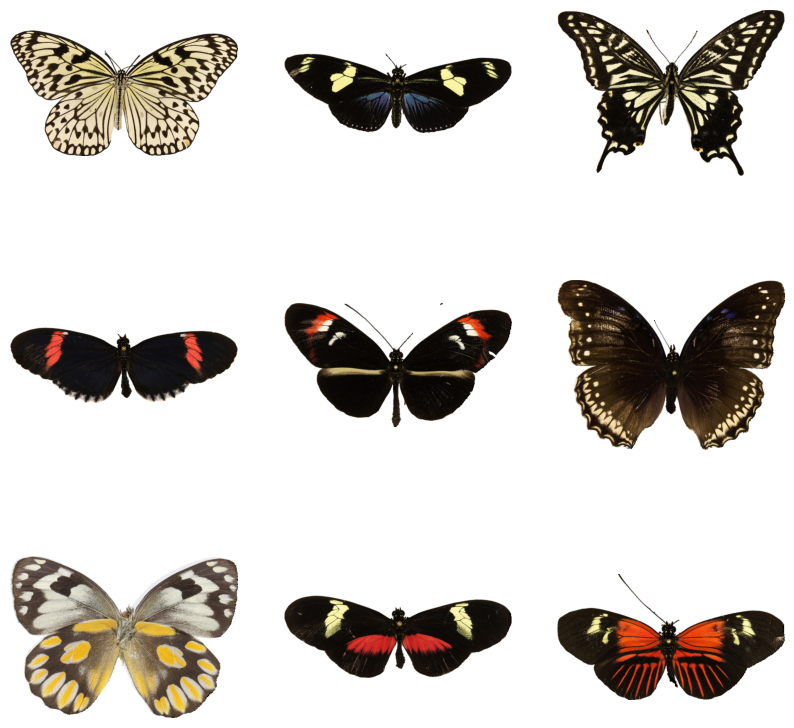

In [82]:
import matplotlib.pyplot as plt   # inspecting dataset
plt.figure(figsize=(10, 10))

for i in range(9):
    image = dataset["train"][i]["image"]

    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.axis("off")

plt.show()

In [83]:
from torchvision import transforms # transformation(preprocessing)

preprocess = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

In [84]:
image_size = 64 #hyperparameters
batch_size = 16
num_epochs = 10
learning_rate = 1e-4
num_train_timesteps = 1000

In [85]:
from diffusers import UNet2DModel # model definition

In [86]:
model = UNet2DModel(
    sample_size=image_size,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(128, 128, 256, 256),
    down_block_types=(  #downsampling/encoder
        "DownBlock2D",
        "DownBlock2D",
        "AttnDownBlock2D",
        "AttnDownBlock2D",
    ),
    up_block_types=( #upsampling/decoder
        "AttnUpBlock2D",
        "AttnUpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
    ),
)

In [87]:
from diffusers import DDPMScheduler #nooise scheduler configuration

noise_scheduler = DDPMScheduler(
    num_train_timesteps=num_train_timesteps
)

print(noise_scheduler)

DDPMScheduler {
  "_class_name": "DDPMScheduler",
  "_diffusers_version": "0.39.0",
  "beta_end": 0.02,
  "beta_schedule": "linear",
  "beta_start": 0.0001,
  "clip_sample": true,
  "clip_sample_range": 1.0,
  "dynamic_thresholding_ratio": 0.995,
  "num_train_timesteps": 1000,
  "prediction_type": "epsilon",
  "rescale_betas_zero_snr": false,
  "sample_max_value": 1.0,
  "steps_offset": 0,
  "thresholding": false,
  "timestep_spacing": "leading",
  "trained_betas": null,
  "variance_type": "fixed_small"
}



In [88]:
import torch #cuda compatible or not

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

print(device)

cuda


In [89]:
optimizer = torch.optim.AdamW( #optimizer
    model.parameters(),
    lr=learning_rate
)

In [90]:
def transform_images(examples): #preprocess dataset for dataloaders
    images = [
        preprocess(image.convert("RGB"))
        for image in examples["image"]
    ]

    return {
        "images": images
    }

In [91]:
dataset["train"].set_transform(transform_images)

In [92]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    dataset["train"],
    batch_size=batch_size,
    shuffle=True
)

In [93]:
num_epochs = 10

for epoch in range(num_epochs):

    model.train()
    total_loss = 0

    for batch in train_loader:

        clean_images = batch["images"].to(device)

        # Generate random Gaussian noise
        noise = torch.randn_like(clean_images)

        # Random timestep for each image
        timesteps = torch.randint(
            0,
            num_train_timesteps,
            (clean_images.shape[0],),
            device=device
        ).long()

        # Add noise to the images
        noisy_images = noise_scheduler.add_noise(
            clean_images,
            noise,
            timesteps
        )

        # Predict the noise
        noise_pred = model(
            noisy_images,
            timesteps
        ).sample

        # Calculate loss
        loss = torch.nn.functional.mse_loss(
            noise_pred,
            noise
        )

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    print(
        f"Epoch {epoch + 1}/{num_epochs}, "
        f"Loss: {avg_loss:.4f}"
    )

Epoch 1/10, Loss: 0.1815
Epoch 2/10, Loss: 0.0723
Epoch 3/10, Loss: 0.0616
Epoch 4/10, Loss: 0.0465
Epoch 5/10, Loss: 0.0447
Epoch 6/10, Loss: 0.0404
Epoch 7/10, Loss: 0.0324
Epoch 8/10, Loss: 0.0344
Epoch 9/10, Loss: 0.0305
Epoch 10/10, Loss: 0.0323


In [94]:
clean_images = batch["images"].to(device)

In [95]:
noise = torch.randn_like(clean_images)

In [96]:
timesteps = torch.randint(
    0,
    num_train_timesteps,
    (clean_images.shape[0],),
    device=device
).long()

In [97]:
noisy_images = noise_scheduler.add_noise(
    clean_images,
    noise,
    timesteps
)

In [98]:
noise_pred = model(
    noisy_images,
    timesteps
).sample

In [99]:
loss = torch.nn.functional.mse_loss(
    noise_pred,
    noise
)

In [100]:
optimizer.zero_grad()
loss.backward()
optimizer.step()

In [101]:
avg_loss = total_loss / len(train_loader)

In [102]:
print(
    f"Epoch {epoch + 1}/{num_epochs}, " #epoch wise monitoring
    f"Loss: {avg_loss:.4f}"
)

Epoch 10/10, Loss: 0.0323


In [103]:
print(len(train_loader))

63


In [104]:
print(
    f"Epoch {epoch + 1}/{num_epochs}, "
    f"Loss: {avg_loss:.4f}"
)

Epoch 10/10, Loss: 0.0323


In [105]:
losses = []

In [106]:
losses.append(avg_loss)

In [107]:
for epoch in range(num_epochs):

    model.train()
    total_loss = 0

    for batch in train_loader:

        clean_images = batch["images"].to(device)

        # Generate random Gaussian noise
        noise = torch.randn_like(clean_images)

        # Select random timestep
        timesteps = torch.randint(
            0,
            num_train_timesteps,
            (clean_images.shape[0],),
            device=device
        ).long()

        # Add noise
        noisy_images = noise_scheduler.add_noise(
            clean_images,
            noise,
            timesteps
        )

        # Predict noise
        noise_pred = model(
            noisy_images,
            timesteps
        ).sample

        # MSE loss
        loss = torch.nn.functional.mse_loss(
            noise_pred,
            noise
        )

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    losses.append(avg_loss)

    print(
        f"Epoch {epoch + 1}/{num_epochs}, "
        f"Loss: {avg_loss:.6f}"
    )

Epoch 1/10, Loss: 0.031803
Epoch 2/10, Loss: 0.030234
Epoch 3/10, Loss: 0.031044
Epoch 4/10, Loss: 0.027834
Epoch 5/10, Loss: 0.030611
Epoch 6/10, Loss: 0.027865
Epoch 7/10, Loss: 0.030494
Epoch 8/10, Loss: 0.027890
Epoch 9/10, Loss: 0.024783
Epoch 10/10, Loss: 0.029568


In [108]:
print(losses)

[0.03228905974399476, 0.03180321833000533, 0.030234083947208192, 0.031044441112686717, 0.02783369201989401, 0.030610701350110864, 0.027865360165754006, 0.030494053877653585, 0.02789031099971561, 0.02478282537961763, 0.029567517665407016]


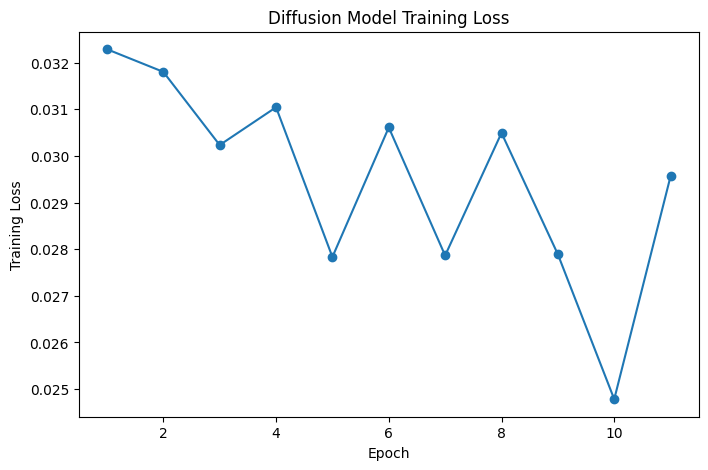

In [122]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, len(losses) + 1), losses, marker="o")

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Diffusion Model Training Loss")

plt.show()

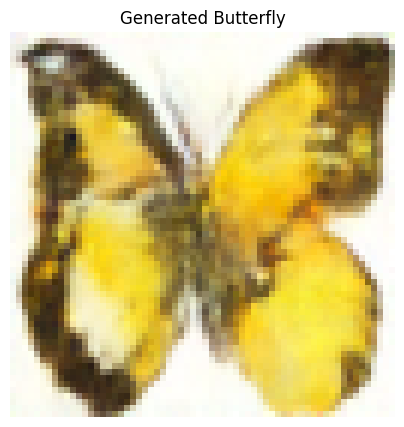

In [110]:
model.eval()

sample = torch.randn(
    1,
    3,
    image_size,
    image_size,
    device=device
)

noise_scheduler.set_timesteps(num_train_timesteps)

with torch.no_grad():

    for t in noise_scheduler.timesteps:

        noise_pred = model(
            sample,
            t
        ).sample

        sample = noise_scheduler.step(
            noise_pred,
            t,
            sample
        ).prev_sample

image = (sample / 2 + 0.5).clamp(0, 1)

image = image.cpu().permute(0, 2, 3, 1).numpy()

plt.figure(figsize=(5, 5))
plt.imshow(image[0])
plt.axis("off")
plt.title("Generated Butterfly")
plt.show()

In [111]:
min_loss = min(losses)
min_epoch = losses.index(min_loss) + 1

print("Minimum Loss:", min_loss)
print("Best Epoch:", min_epoch)

Minimum Loss: 0.02478282537961763
Best Epoch: 10


In [112]:
print("Initial Loss:", losses[0])
print("Final Loss:", losses[-1])

Initial Loss: 0.03228905974399476
Final Loss: 0.029567517665407016


In [113]:
reduction = ((losses[0] - losses[-1]) / losses[0]) * 100

print("Loss reduction:", reduction, "%")

Loss reduction: 8.428681727388806 %


In [114]:
noise = torch.randn_like(clean_images)

In [115]:
timesteps = torch.randint(
    0,
    num_train_timesteps,
    (batch_size,),
    device=device
).long()

In [116]:
import numpy as np

print("Initial Loss:", losses[0])
print("Final Loss:", losses[-1])
print("Minimum Loss:", min(losses))
print("Best Epoch:", losses.index(min(losses)) + 1)

reduction = ((losses[0] - losses[-1]) / losses[0]) * 100
print("Overall Loss Reduction:", reduction, "%")

Initial Loss: 0.03228905974399476
Final Loss: 0.029567517665407016
Minimum Loss: 0.02478282537961763
Best Epoch: 10
Overall Loss Reduction: 8.428681727388806 %


In [117]:
num_images = 8 #result visualization

samples = torch.randn(
    num_images,
    3,
    image_size,
    image_size,
    device=device
)

noise_scheduler.set_timesteps(num_train_timesteps)

model.eval()

with torch.no_grad():
    for t in noise_scheduler.timesteps:

        noise_pred = model(
            samples,
            t
        ).sample

        samples = noise_scheduler.step(
            noise_pred,
            t,
            samples
        ).prev_sample

In [118]:
samples = (samples / 2 + 0.5).clamp(0, 1)

In [119]:
samples = samples.cpu().permute(0, 2, 3, 1).numpy()

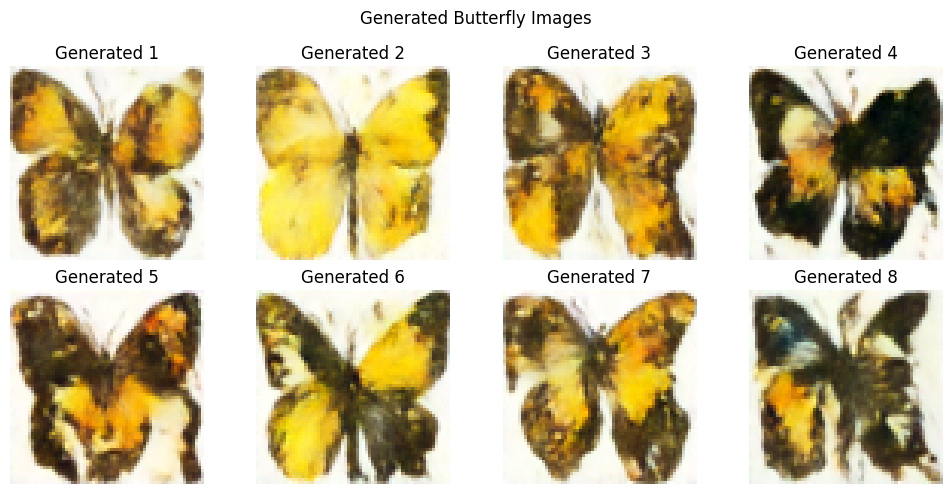

In [120]:
fig, axes = plt.subplots(2, 4, figsize=(10, 5))

for i, ax in enumerate(axes.flat):

    ax.imshow(samples[i])
    ax.axis("off")
    ax.set_title(f"Generated {i+1}")

plt.suptitle("Generated Butterfly Images")
plt.tight_layout()
plt.show()

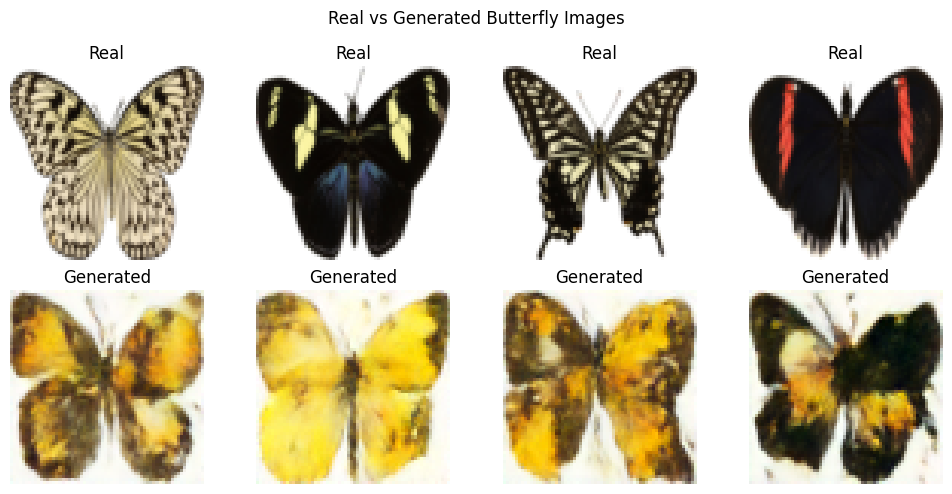

In [121]:
fig, axes = plt.subplots(2, 4, figsize=(10, 5))

# Real images
for i in range(4):
    # Access the transformed 'images' key
    real_image_tensor = dataset["train"][i]["images"]

    # Denormalize and reformat for display
    real_image_display = (real_image_tensor * 0.5 + 0.5).clamp(0, 1).cpu().permute(1, 2, 0).numpy()

    axes[0, i].imshow(real_image_display)
    axes[0, i].axis("off")
    axes[0, i].set_title("Real")

# Generated images
for i in range(4):
    axes[1, i].imshow(samples[i])
    axes[1, i].axis("off")
    axes[1, i].set_title("Generated")

plt.suptitle("Real vs Generated Butterfly Images")
plt.tight_layout()
plt.show()